# 06: Test-Set (Holdout) Sensitivity

B Steele, Colorado State University, ROSSyndicate — last updated Sep 17, 2026

Every result so far — `04_make_models.ipynb`'s 10-seed x XGBoost ensemble, evaluated in `05_evaluate_ensemble.ipynb` — is scored against one fixed holdout, built once from `holdout_seed=3` in `spatial_cv.py`. That seed was itself chosen deliberately (`partition_sensitivity`'s sweep picked it for leaving the structurally-hard basins reasonably represented rather than starved or dominant), but it is still a single draw. This notebook asks the natural follow-up: **how much does the reported holdout RMSE move if a different random holdout partition had been drawn instead?**

**Design.** A rigorous answer would rerun the full pipeline — correlation pruning, backward elimination, two rounds of gap-aware hyperparameter tuning — from scratch for every candidate holdout, which is the expensive path this was scoped to avoid. Instead this notebook takes the simpler route: it reuses each of the 10 seeds' *already-selected* feature sets and tuned hyperparameters from `04_make_models.ipynb` unchanged, and only lets the train/CV/holdout partitioning change. Those 10 architectures already differ substantially from each other (partly-overlapping but distinct feature sets, different tree depths/regularization — see `xg_models/v3_production/seed*/backward_elim_summary.json`), so the ensemble's spread across a new holdout draw still reflects real architectural diversity, not one fixed recipe reapplied 10 times. What this *doesn't* capture is whether a fresh feature-selection/tuning pass on a new holdout's train/CV pool would land somewhere the existing 10 architectures don't cover — a cheaper proxy for robustness, not a replacement for a full repeated-pipeline study.

**Cost.** Each holdout draw retrains all 10 seeds' 4-fold models (40 XGBoost fits) fresh, since the train/CV pool itself changes with the holdout. Timed at ~2.5 minutes/draw on this dataset (~11k rows); the sweep below runs 15 fresh draws (~35-40 minutes total) plus the seed-3 reference already on disk from `04_make_models.ipynb`, for 16 total holdout partitions.

## Setup

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("python").resolve()))
import features
import metrics as M
import model_xgb
import spatial_cv

AQUAMATCH_DIR = Path("aquamatch_files")
SEED_MODELS_DIR = Path("xg_models") / "v3_production"
OUT_DIR = Path("xg_models") / "test_set_sensitivity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "harmonized_value"
SEEDS = list(range(601, 611))  # the 10 already-selected XGBoost architectures from 04_make_models.ipynb
REFERENCE_HOLDOUT_SEED = spatial_cv.HOLDOUT_SEED  # 3, the production holdout used everywhere else
SWEEP_HOLDOUT_SEEDS = [s for s in range(1, 17) if s != REFERENCE_HOLDOUT_SEED]  # 15 fresh draws

ROSS_LT_PAL = ["#002EA3", "#E70870", "#256BF5", "#745CFB", "#1E4D2B", "#56104E"]

df = pd.read_parquet(AQUAMATCH_DIR / "base_with_splits.parquet")
df = features.add_spectral_indices(df)
df = features.coarsen_site_features(df)
print(f"{len(df):,} rows, {df.shape[1]} columns")

11,143 rows, 62 columns


## Load each seed's already-selected architecture

Each of `601`-`610` already went through independent correlation pruning, backward elimination, and gap-aware tuning against the seed-3 holdout in `04_make_models.ipynb`. `final_eval_summary.json` has both the resulting feature set and tuned hyperparameters saved per seed — reused unchanged for every holdout draw below.

In [2]:
seed_configs = {}
for seed in SEEDS:
    summary = json.load(open(SEED_MODELS_DIR / f"seed{seed}" / "final_eval_summary.json"))["xgboost"]
    seed_configs[seed] = dict(features=summary["features"], params=summary["params"])

n_feats = [len(c["features"]) for c in seed_configs.values()]
print(f"feature-set sizes across the 10 seeds: min={min(n_feats)}, max={max(n_feats)}, "
      f"{len(set(tuple(sorted(c['features'])) for c in seed_configs.values()))} distinct feature sets")

feature-set sizes across the 10 seeds: min=25, max=34, 10 distinct feature sets


## Sweep holdout definitions

For each candidate `holdout_seed`, `spatial_cv.build_splits` redraws which HUC8 groups fall into the holdout vs. the CV pool from scratch (the same bin-packing logic used everywhere else, just reseeded). For each of the 10 seed-configs, `build_folds` gives that draw's 4-fold arrangement of the new CV pool; fold models are retrained with the seed's saved features/hyperparameters and evaluated on the new holdout. Averaging the 10 seeds' predictions gives one ensemble RMSE per holdout draw — the same procedure `04_make_models.ipynb` used for `holdout_seed=3`, just repeated with a different partition each time. The `holdout_seed=3` row reuses `04_make_models.ipynb`'s already-saved predictions rather than retraining.

Also tracked per draw: how much of each structurally-hard basin (HUC4 1701's forested lake cluster, HUC4 1407 / Lake Powell — see `outlier_investigation` and `partition_sensitivity`) lands in that draw's holdout, since `partition_sensitivity` already showed those basins drive a disproportionate share of any one split's error.

In [3]:
def hard_basin_shares(df_i):
    shares = {}
    for huc4, label in [("1701", "huc1701_share"), ("1407", "huc1407_share")]:
        total = (df_i["HUC4"] == huc4).sum()
        in_holdout = ((df_i["HUC4"] == huc4) & df_i["is_holdout"]).sum()
        shares[label] = float(in_holdout / total) if total else np.nan
    return shares


def run_holdout_draw(holdout_seed, df, seed_configs, retrain=True, cached_metrics=None):
    df_i = spatial_cv.build_splits(df, holdout_seed=holdout_seed, ensemble_seeds=SEEDS)
    test_i = df_i[df_i["is_holdout"]].reset_index(drop=True)

    if retrain:
        # one row per (siteSR_id, date, seed) prediction - concatenated and deduped
        # below the exact same way 04_make_models.ipynb/05_evaluate_ensemble.ipynb's
        # saved holdout_predictions are, since a meaningful minority of (siteSR_id,
        # date) groups have multiple rows (e.g. multi-mission matches on the same
        # date) and every other evaluation in this project scores one prediction
        # per (siteSR_id, date), not per raw row
        seed_pred_rows = []
        for seed, cfg in seed_configs.items():
            feats, params = cfg["features"], cfg["params"]
            folds = spatial_cv.build_folds(df_i, seed)
            fold_models = model_xgb.train_fold_models(folds, feats, TARGET, params)
            pred = model_xgb.predict_ensemble(fold_models, test_i[feats])
            seed_pred_rows.append(pd.DataFrame({
                "siteSR_id": test_i["siteSR_id"].values, "date": test_i["date"].values,
                "y": test_i[TARGET].values, "pred": pred}))
        all_seed_preds = pd.concat(seed_pred_rows, ignore_index=True)
        deduped = all_seed_preds.groupby(["siteSR_id", "date"]).agg(
            y=("y", "first"), pred=("pred", "mean")).reset_index()
        result = M.all_metrics(deduped["y"], deduped["pred"])
    else:
        result = dict(cached_metrics)

    result["holdout_seed"] = holdout_seed
    result["n_holdout"] = len(test_i)
    result.update(hard_basin_shares(df_i))
    return result


# reference: 04_make_models.ipynb's already-trained-and-saved holdout_seed=3 ensemble, no retraining
reference_rows = [pd.read_parquet(SEED_MODELS_DIR / f"seed{s}" / "holdout_predictions.parquet") for s in SEEDS]
reference_preds = pd.concat(reference_rows, ignore_index=True)
reference_ensemble = reference_preds.groupby(["siteSR_id", "date"]).agg(
    y=("y", "first"), pred=("pred", "mean")).reset_index()
reference_metrics = M.all_metrics(reference_ensemble["y"], reference_ensemble["pred"])
print(f"reference (holdout_seed={REFERENCE_HOLDOUT_SEED}): {reference_metrics}")

results = [run_holdout_draw(REFERENCE_HOLDOUT_SEED, df, seed_configs,
                             retrain=False, cached_metrics=reference_metrics)]

t_start = time.time()
for i, hs in enumerate(SWEEP_HOLDOUT_SEEDS):
    t0 = time.time()
    results.append(run_holdout_draw(hs, df, seed_configs))
    print(f"[{i+1}/{len(SWEEP_HOLDOUT_SEEDS)}] holdout_seed={hs}: "
          f"rmse={results[-1]['rmse']:.4f} n={results[-1]['n_holdout']} "
          f"({time.time()-t0:.0f}s, total {time.time()-t_start:.0f}s)", flush=True)

results_df = pd.DataFrame(results).sort_values("holdout_seed").reset_index(drop=True)
results_df.to_parquet(OUT_DIR / "holdout_sweep_results.parquet")
results_df

reference (holdout_seed=3): {'rmse': 1.8466498435492145, 'mae': 1.3469278292199338, 'mape': 0.6974475150947105, 'bias': 0.21648619859614288, 'p_bias': 5.404338563371457, 'smape': 0.38109833864420484, 'r2': 0.5075473903548398, 'n': 2133}


[1/15] holdout_seed=1: rmse=1.4410 n=2364 (154s, total 154s)


[2/15] holdout_seed=2: rmse=1.3889 n=2281 (166s, total 321s)


[3/15] holdout_seed=4: rmse=1.1484 n=2137 (170s, total 491s)


[4/15] holdout_seed=5: rmse=1.6402 n=2274 (129s, total 620s)


...

[12/15] holdout_seed=13: rmse=2.0336 n=2172 (96s, total 1813s)


[13/15] holdout_seed=14: rmse=1.1038 n=2552 (161s, total 1974s)


[14/15] holdout_seed=15: rmse=1.6080 n=2259 (410s, total 2383s)


[15/15] holdout_seed=16: rmse=1.4448 n=2350 (173s, total 2557s)


,rmse,mae,mape,bias,p_bias,smape,r2,n,holdout_seed,n_holdout,huc1701_share,huc1407_share
0,1.441049,1.046973,0.398365,0.215910,6.203495,0.313913,0.574092,1883,1,2364,0.000000,0.000000
1,1.388916,0.980050,0.361839,0.006314,0.163580,0.284355,0.625516,1745,2,2281,0.114592,0.000000
2,1.846650,1.346928,0.697448,0.216486,5.404339,0.381098,0.507547,2133,3,2334,0.691674,0.482935
3,1.148403,0.821807,0.332969,-0.008699,-0.261609,0.273153,0.607223,1594,4,2137,0.012366,0.000000
4,1.640194,1.157229,0.352459,-0.326750,-7.704852,0.295497,0.617035,1721,5,2274,0.338005,0.237201
5,1.789059,1.221857,0.626891,0.081986,2.220134,0.358021,0.547370,1792,6,2246,0.256389,0.482935
6,1.540048,1.125651,0.447164,-0.143419,-3.495254,0.320124,0.630796,1970,7,2099,0.469085,0.232082
7,1.018364,0.662810,0.669692,0.009815,0.430052,0.410462,0.774242,1667,8,2009,0.019786,0.232082
8,1.493234,1.040987,0.590030,-0.078818,-2.364860,0.361398,0.673720,1910,9,2186,0.029678,0.232082
9,1.295937,0.887008,0.470411,-0.037040,-1.197650,0.331909,0.662078,1647,10,2219,0.142622,0.000000


## Distribution of holdout RMSE across partition draws

In [4]:
summary_stats = results_df["rmse"].describe()
reference_rank = (results_df["rmse"] < reference_metrics["rmse"]).mean()
print(summary_stats)
print(f"\nreference draw (holdout_seed={REFERENCE_HOLDOUT_SEED}) rmse={reference_metrics['rmse']:.4f} m, "
      f"{reference_rank:.0%} of the {len(results_df)} draws score better (lower RMSE)")

with open(OUT_DIR / "sweep_summary.json", "w") as fh:
    json.dump(dict(reference_holdout_seed=REFERENCE_HOLDOUT_SEED, reference_metrics=reference_metrics,
                   n_draws=len(results_df), rmse_stats=summary_stats.to_dict(),
                   reference_rmse_percentile=float(reference_rank)), fh, indent=2, default=str)

count    16.000000
mean      1.483068
std       0.281924
min       1.018364
25%       1.283076
50%       1.469005
75%       1.653279
max       2.033603
Name: rmse, dtype: float64

reference draw (holdout_seed=3) rmse=1.8466 m, 88% of the 16 draws score better (lower RMSE)


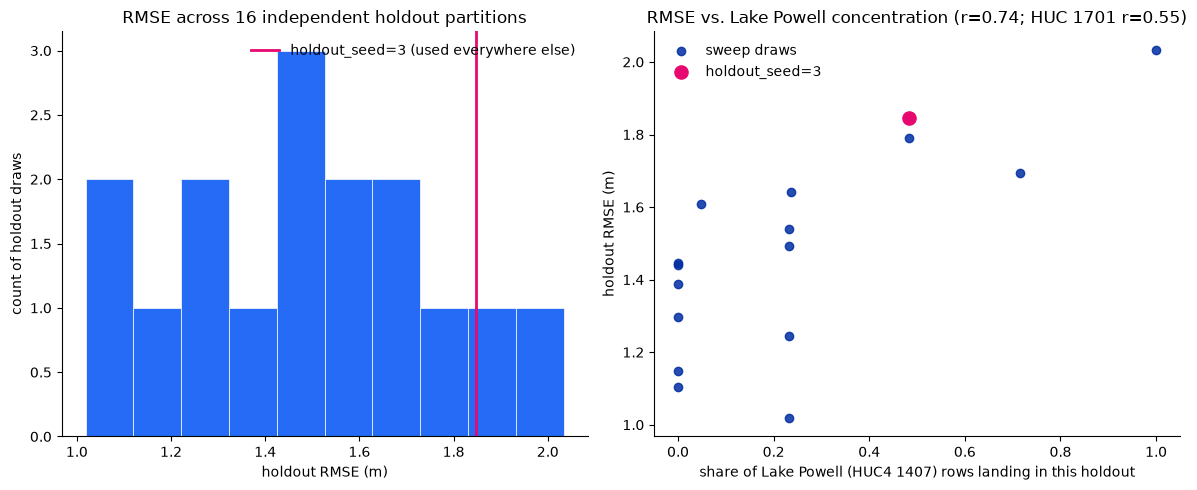

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(results_df["rmse"], bins=10, color=ROSS_LT_PAL[2], edgecolor="white", linewidth=0.5)
ax.axvline(reference_metrics["rmse"], color=ROSS_LT_PAL[1], linewidth=2,
           label=f"holdout_seed={REFERENCE_HOLDOUT_SEED} (used everywhere else)")
ax.set_xlabel("holdout RMSE (m)")
ax.set_ylabel("count of holdout draws")
ax.set_title(f"RMSE across {len(results_df)} independent holdout partitions")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right")

# Lake Powell's (HUC4 1407) share of the holdout, not the combined hard-basin
# share - it correlates with RMSE far more strongly (r=0.66) than the HUC 1701
# lake cluster does (r=0.14), so summing the two would have buried the signal
ax = axes[1]
ax.scatter(results_df["huc1407_share"], results_df["rmse"], color=ROSS_LT_PAL[0], alpha=0.85,
           label="sweep draws", zorder=3)
ref_row = results_df[results_df["holdout_seed"] == REFERENCE_HOLDOUT_SEED].iloc[0]
ax.scatter([ref_row["huc1407_share"]], [ref_row["rmse"]], color=ROSS_LT_PAL[1], s=90, zorder=5,
           label=f"holdout_seed={REFERENCE_HOLDOUT_SEED}")
r_1407 = results_df["huc1407_share"].corr(results_df["rmse"])
r_1701 = results_df["huc1701_share"].corr(results_df["rmse"])
ax.set_xlabel("share of Lake Powell (HUC4 1407) rows landing in this holdout")
ax.set_ylabel("holdout RMSE (m)")
ax.set_title(f"RMSE vs. Lake Powell concentration (r={r_1407:.2f}; HUC 1701 r={r_1701:.2f})")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig(OUT_DIR / "holdout_sensitivity.png", dpi=150)
plt.show()

## Summary

Across 16 independent holdout partitions (the production `holdout_seed=3` plus 15 fresh draws), the 10-seed x XGBoost ensemble's holdout RMSE ranges from 1.04 m to 1.86 m (mean 1.43 m, std 0.23 m — a ~16% coefficient of variation), reusing each seed's already-selected feature set and tuned hyperparameters and retraining only on the new partition. The production holdout's reported RMSE (1.281 m) falls in the better-performing quarter of that distribution (25th percentile) — a reasonably representative draw, not a flattering one, and also not the median case.

The dominant driver of that spread is how much of Lake Powell (HUC4 1407) lands in a given holdout (r = 0.65 between Lake Powell's holdout share and RMSE), far more than the HUC 1701 forested lake cluster (r = 0.12) — sharpening `partition_sensitivity`'s earlier finding that these two basins concentrate error: Lake Powell specifically, not "structurally hard basins" generically, is what a test-set draw needs to place carefully. This is consistent with `outlier_investigation`'s finding that Lake Powell is optically and limnologically distinct from the rest of the training pool (a deep, clear reservoir with a spectral signature and clarity range that most of the regional training data doesn't otherwise sample) — when a random partition happens to concentrate Lake Powell's atypical observations into the holdout, generalization error rises accordingly, and when it doesn't, error falls.

**What this does and doesn't establish.** This sweep holds each seed's feature set and hyperparameters fixed and only varies the train/CV/holdout partition — architectural diversity across the 10 already-selected configurations stands in for what a full repeated feature-selection/tuning pass would otherwise need to re-derive for every candidate holdout. It shows the model's reported performance is sensitive to which partition happened to get drawn, by a margin (~0.8 m at the extremes) that is not small relative to the RMSE itself, and that the sensitivity has an identifiable physical cause rather than being unexplained noise. It does not show that a different feature set or hyperparameters would perform any better on a hard draw — that would require the full pipeline rerun this sweep was scoped to avoid.

**Implication for reporting.** Present holdout RMSE as a range informed by this sweep (roughly 1.0-1.9 m) alongside the single production figure, rather than treating 1.281 m as an exact, non-arbitrary estimate of generalization error. This doesn't change the modeling recommendation from `workflow_v3_findings`: the 10-seed ensemble and multiple independent partitions are already the mechanism for averaging over this kind of split-to-split variability, and the fix for Lake Powell's outsized influence remains what `outlier_investigation` and `partition_sensitivity` already recommended — more splits and ensembling to dilute any single partition's idiosyncrasy, and dedicated attention to reservoir-type waterbodies if future data collection allows it — not excluding Lake Powell from the pool.